# Sales Prediction Using Python

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [87]:
sales_df = pd.read_csv("Advertising_data.csv")
sales_df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [88]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [89]:
sales_df = sales_df.drop(columns=["Unnamed: 0"], errors="ignore")
sales_df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [90]:
sales_df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

### The pairplot suggests TV spend has the strongest positive relationship with Sales, followed by Radio. Newspaper spend shows little to no visible correlation with Sales.

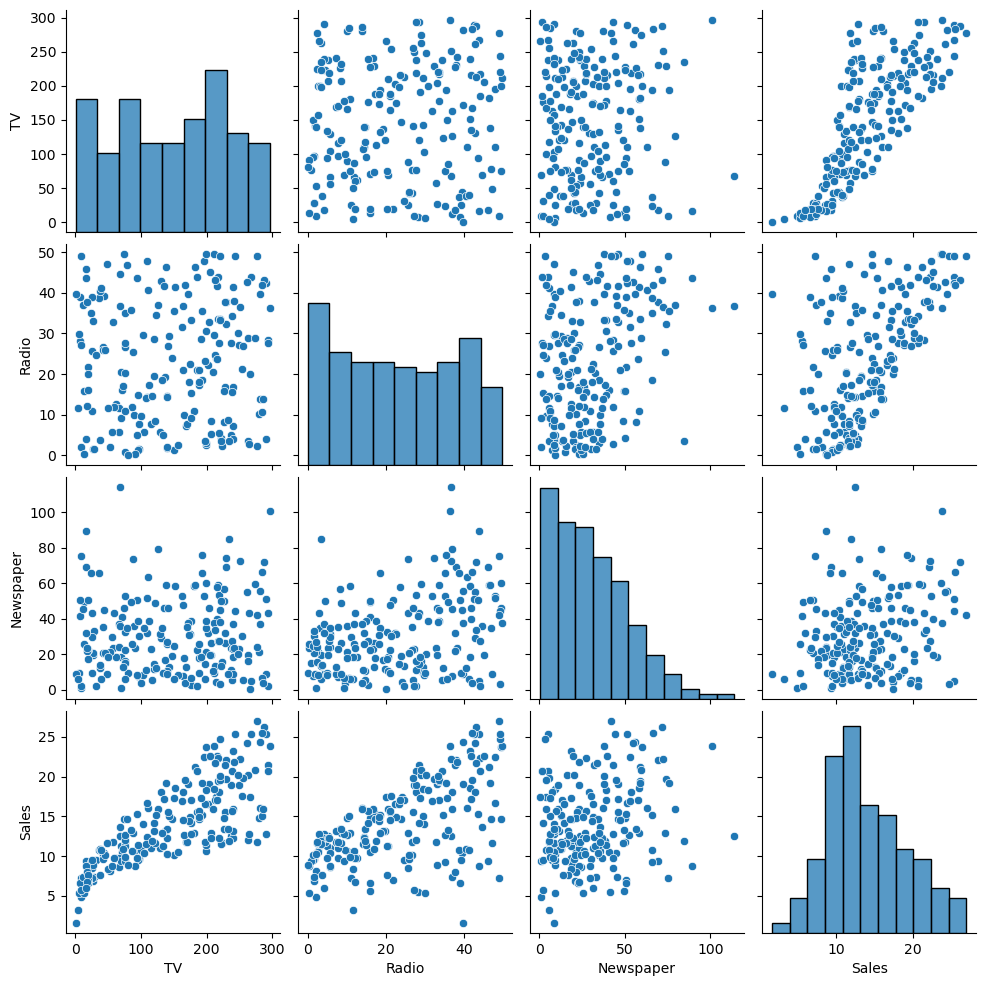

In [91]:
sns.pairplot(sales_df)
plt.show()

### These individual scatter plots confirm TV spend has the strongest linear relationship with Sales, Radio shows a moderate positive relationship, and Newspaper spend shows little to no clear relationship with Sales.

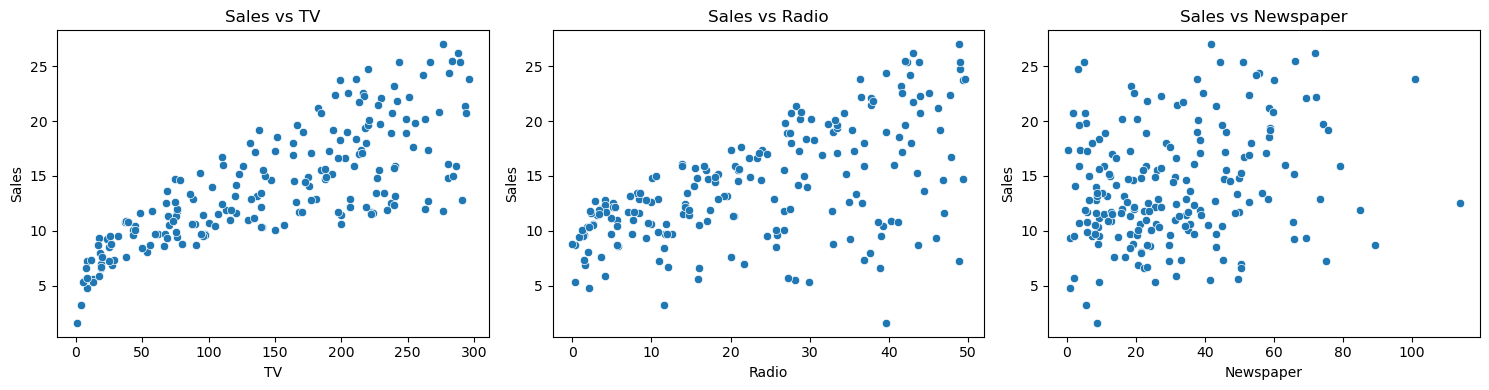

In [92]:
# Individual scatter plots for each feature against sales

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x="TV", y="Sales", data=sales_df, ax=axes[0])
sns.scatterplot(x="Radio", y="Sales", data=sales_df, ax=axes[1])
sns.scatterplot(x="Newspaper", y="Sales", data=sales_df, ax=axes[2])

axes[0].set_title('Sales vs TV')
axes[1].set_title('Sales vs Radio')
axes[2].set_title('Sales vs Newspaper')

plt.tight_layout()
plt.show()

### The correlation heatmap confirms TV spend has the strongest correlation with Sales (0.78), followed by Radio (0.58), while Newspaper shows a weak correlation (0.23). This suggests TV and Radio advertising are likely to be the strongest predictors of sales.

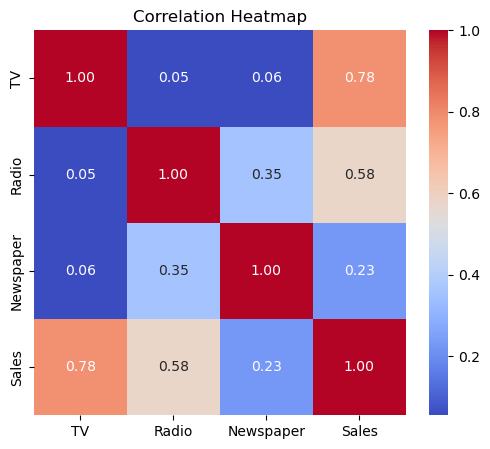

In [93]:
plt.figure(figsize=(6, 5))
sns.heatmap(sales_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [94]:
# Test train split 
X = sales_df.drop(columns=["Sales"])
y = sales_df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [95]:
X_train

,TV,Radio,Newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6
...,...,...,...
106,25.0,11.0,29.7
14,204.1,32.9,46.0
92,217.7,33.5,59.0
179,165.6,10.0,17.6


In [96]:
# Linear Model 
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [97]:
y_pred_linear = linear_model.predict(X_test)
y_pred_linear

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [98]:
# Random Forest Model
random_model = RandomForestRegressor(n_estimators=100,random_state=42)
random_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [99]:
y_pred_random = random_model.predict(X_test)
y_pred_random

array([17.698, 21.804, 20.628,  6.793, 22.927, 13.379, 22.376,  9.688,
       11.826, 15.54 ,  7.344,  9.059, 12.109,  4.826, 10.522, 12.69 ,
        6.49 , 16.44 , 11.368, 19.732, 20.181, 12.884, 10.33 , 22.178,
        9.993,  9.006, 22.169, 12.676, 10.201,  5.296, 11.519, 10.904,
       22.165,  8.63 , 15.288, 20.56 , 12.147, 20.523, 12.271,  7.57 ])

### Through Evaluation : Random Forest significantly outperformed Linear Regression across all metrics (MAE: 0.62 vs 1.46,    RMSE: 0.77 vs 1.78,     R²: 0.98 vs 0.89), suggesting the relationship between advertising spend and sales is not purely linear. 
### Random Forest is selected as the best-performing model.

In [100]:
# Evaluate 
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results\n")
print(f"Mean Absolute Error: {mae_linear}")
print(f"Root Mean Square Error: {rmse_linear}")
print(f"R2 Score: {r2_linear}")

Linear Regression Results

Mean Absolute Error: 1.4607567168117606
Root Mean Square Error: 1.7815996615334502
R2 Score: 0.899438024100912


In [101]:
# Evaluate 
mae_random = mean_absolute_error(y_test, y_pred_random)
rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))
r2_random = r2_score(y_test, y_pred_random)

print("Random Forest Results\n")
print(f"Mean Absolute Error: {mae_random}")
print(f"Root Mean Square Error: {rmse_random}")
print(f"R2 Score: {r2_random}")

Random Forest Results

Mean Absolute Error: 0.6200999999999988
Root Mean Square Error: 0.7685910811348248
R2 Score: 0.9812843792541843


## Residual Plot - For Best Performing Model i.e., Random Forest Model

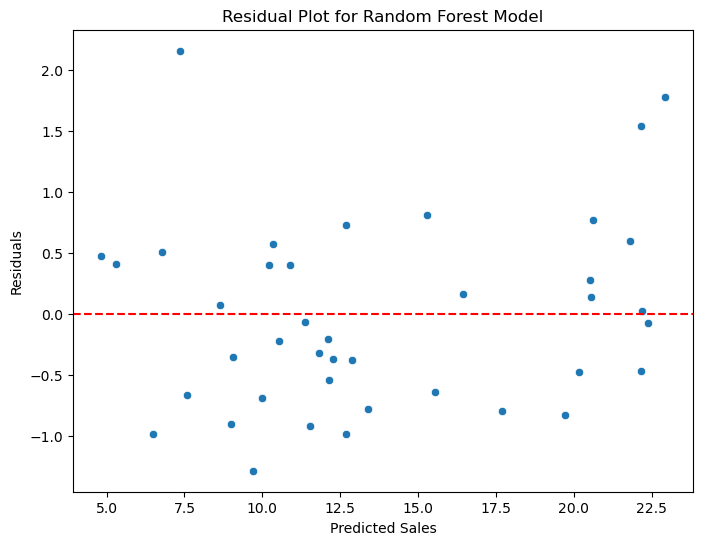

In [102]:
residuals = y_test - y_pred_random

plt.figure(figsize=(8, 6))

sns.scatterplot(x = y_pred_random, y = residuals)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot for Random Forest Model")
plt.show()

### The residual plot shows points randomly scattered around zero with no clear pattern, indicating the Random Forest model's errors are largely random rather than systematic. This supports the model being a good fit for the data.

## Interpretation --------

In [103]:
importances = pd.Series(random_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

TV           0.624810
Radio        0.362201
Newspaper    0.012989
dtype: float64

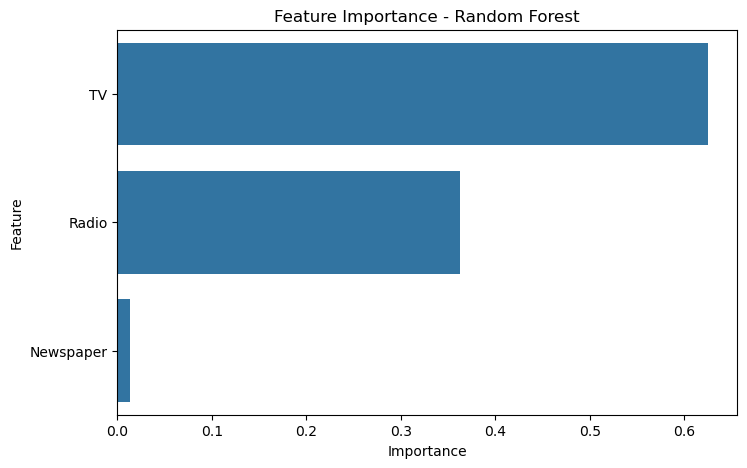

In [104]:
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

### Feature importance from the Random Forest model confirms TV spend as the most influential factor in predicting sales, followed by Radio. Newspaper spend has minimal predictive value, consistent with the weak correlation observed earlier.

## ---

## Conclusion
### - Correlation analysis showed TV spend has the strongest relationship with Sales (0.78), followed by Radio (0.58), while Newspaper spend showed weak correlation (0.23).
### - Model comparison: Random Forest significantly outperformed Linear Regression across all metrics (MAE: 0.62 vs 1.46, RMSE: 0.77 vs 1.78, R²: 0.98 vs 0.89), indicating the relationship between advertising spend and sales is not purely linear.
### - Residual analysis confirmed the Random Forest model's errors are randomly distributed with no systematic pattern, supporting it as a well-fitted model.
### - Feature importance confirmed TV as the most influential advertising channel (~60% importance), followed by Radio (~35%), with Newspaper contributing minimally (~3%).
### - Business takeaway: Based on this analysis, advertising budget should be prioritized toward TV and Radio channels, as Newspaper advertising shows little to no measurable impact on sales in this dataset.